In [67]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from io import StringIO
import warnings, os
from IPython.display import Image, display
warnings.filterwarnings('ignore')

OUT = 'outputs'
os.makedirs(OUT, exist_ok=True)

C1='#1B2A4A'; C2='#2E6DA4'; C3='#4DAFE0'; C4='#7DCFE8'; C5='#B8E4F5'
ACC='#E85D26'; ACC2='#F5A623'; BG='#F7F9FC'
SEG_COLORS={'Champions':'#1B2A4A','Loyal Customers':'#2E6DA4','Potential Loyalists':'#4DAFE0',
            'At-Risk Customers':'#F5A623','Dormant / Lost':'#E85D26'}
SALE_COLORS={'High Value':'#1B2A4A','Medium Value':'#2E6DA4','Low Value':'#4DAFE0','Dormant':'#E85D26'}
seg_order=['Champions','Loyal Customers','Potential Loyalists','At-Risk Customers','Dormant / Lost']

rfm_data = """CustomerID,Recency,Frequency,Monetary
12377,5124,43,1001.52
17069,5124,26,583.20
16684,5124,23,3113.40
14646,5124,16,70.96
16153,5124,10,215.01
17841,5125,287,2473.07
14911,5125,248,6685.79
15640,5125,106,2766.69
17218,5125,97,606.28
16686,5125,86,364.98
15044,5125,84,1499.75
17243,5125,45,855.05
15581,5125,45,316.76
17358,5125,42,246.70
18077,5125,36,396.33
14472,5125,36,279.88
17913,5125,31,218.05
14032,5125,29,619.42
18245,5125,27,365.73
12668,5125,24,469.87
17343,5125,17,193.64
12748,5127,642,4119.24
15570,5127,114,1064.64
12370,5127,91,1868.02
16931,5127,81,364.66
12471,5127,76,3874.36
12647,5127,47,1193.60
12720,5127,45,657.13
17377,5127,44,785.08
17865,5127,42,1079.83
16558,5127,42,880.55
15856,5127,39,2312.54
14016,5127,39,753.74
12839,5127,37,737.45
14146,5127,35,1241.43
14031,5127,34,2568.95
12621,5127,32,1383.65
12395,5127,31,679.92
12705,5127,30,858.00
16885,5127,30,190.65
17315,5127,27,108.92
17404,5127,26,3834.30
12431,5127,24,773.95
17790,5127,24,399.55
15811,5127,23,438.80
13004,5127,23,357.01
12782,5127,22,463.50
14769,5127,22,347.01
13869,5127,21,323.62
12971,5127,21,321.59
13627,5127,20,311.19
14243,5127,19,472.00
12709,5127,14,1315.69
14560,5127,14,408.17
17007,5127,12,207.12
15780,5127,12,177.15
13854,5127,11,609.44
12417,5127,11,291.34
13033,5127,11,190.55
12551,5127,10,168.00
15204,5127,9,316.58
16607,5127,8,654.82
16013,5127,7,2973.00
12600,5127,7,274.80
15291,5127,6,648.90
12726,5127,6,170.28
12691,5127,5,180.00
15160,5127,4,158.16
16353,5127,3,408.00
17888,5127,3,29.43
12931,5127,2,177.00
16711,5127,1,214.20
14606,5128,186,1028.15
15574,5128,159,590.15
15311,5128,149,2285.91
14723,5128,90,471.00
13089,5128,86,5953.21
18055,5128,82,1751.12
15601,5128,76,1236.45
15194,5128,71,1558.99
18116,5128,66,311.88
15379,5128,61,1491.46
13767,5128,57,2439.36
15157,5128,54,1085.46
13050,5128,53,930.37
13468,5128,53,911.00
17062,5128,52,435.73
15532,5128,50,356.35
14985,5128,50,124.51
13093,5128,49,3795.51
14180,5128,49,896.25
17392,5128,49,312.41
13694,5128,46,2897.04
14713,5128,44,425.85
16470,5128,39,216.34
13408,5128,38,3031.20
16210,5128,37,7000.64
15620,5128,31,424.49
17068,5128,31,297.45
16539,5128,30,747.25
18176,5128,30,476.35
16743,5128,30,430.28
16670,5128,29,403.61
16029,5128,28,12633.12
14849,5128,28,566.89
15789,5128,25,351.30
15394,5128,24,587.66
15563,5128,22,270.19
18223,5128,21,501.69
17412,5128,21,447.76
16560,5128,21,332.18
14334,5128,20,320.15
16316,5128,20,308.22
12967,5128,19,1660.90
14841,5128,19,395.16
17744,5128,19,377.52
17691,5128,19,290.40
16945,5128,19,279.85
16985,5128,18,933.32
13874,5128,18,540.45
14825,5128,18,396.43
12348,5128,17,892.80
17659,5128,17,359.95
13756,5128,16,1004.40
14621,5128,16,305.70
17146,5128,16,298.25
16271,5128,16,133.22
16705,5128,15,1131.72
14643,5128,15,357.94
14709,5128,15,314.10
16037,5128,15,300.46
16525,5128,14,802.44
14344,5128,14,355.65
15224,5128,14,322.08
13317,5128,14,238.05
12877,5128,14,150.06
14878,5128,13,322.01
14092,5128,13,250.65
17001,5128,12,397.96
16770,5128,12,262.20
15246,5128,12,186.00
13199,5128,11,711.80
14220,5128,11,312.98
16746,5128,11,311.64
13534,5128,11,283.20
18260,5128,11,230.70
13890,5128,11,190.35
17496,5128,10,271.05
17951,5128,9,409.50
15482,5128,8,723.64
14414,5128,8,217.20
15366,5128,8,105.54
13021,5128,7,157.35
17288,5128,7,133.56
14309,5128,6,147.75
17857,5128,5,1340.70
14735,5128,5,252.20
17848,5128,5,97.30
16816,5128,5,75.78
15759,5128,4,97.24
14373,5128,4,76.55
12494,5128,4,62.55
12980,5128,3,889.32
15197,5128,3,556.50
17580,5128,3,46.85
15061,5129,124,19950.66
16782,5129,95,577.99
17511,5129,88,6711.08
14527,5129,86,786.64
16725,5129,75,327.20
17449,5129,73,684.26
15005,5129,73,470.41
17894,5129,71,380.51
15727,5129,67,1536.85
12577,5129,67,195.89
16161,5129,62,576.30
13124,5129,61,1256.32
13418,5129,49,1579.62
17346,5129,47,247.84
17551,5129,43,306.84
18168,5129,39,449.94
17189,5129,38,227.22
17912,5129,36,289.41
13221,5129,35,498.16
13458,5129,30,1185.86
13078,5129,29,881.16
15950,5129,29,428.82
17858,5129,27,1556.85
13496,5129,26,501.01
15456,5129,26,243.22
15615,5129,25,1081.19
17692,5129,25,343.26
17230,5129,22,1761.26
13495,5129,22,865.43
16003,5129,20,1181.00
15641,5129,20,308.37
15384,5129,20,303.57
12928,5129,17,392.34
16145,5129,17,302.78
14913,5129,17,300.87
14060,5129,16,874.04
15373,5129,16,537.10
15822,5129,16,440.20
16134,5129,16,283.53
16817,5129,15,367.30
13611,5129,15,303.15
17980,5129,15,295.20
14401,5129,15,247.38
17214,5129,14,171.05
15465,5129,12,867.85
16954,5129,12,346.80
14150,5129,12,306.18
13491,5129,12,196.40
17629,5129,11,238.65
15062,5129,11,209.08
13295,5129,10,201.20
17525,5129,9,422.70
13426,5129,9,336.98
17454,5129,9,165.85
17033,5129,8,307.80
15290,5129,8,219.60
16365,5129,7,368.46
13092,5129,7,185.45
15512,5129,6,101.20
18050,5129,5,74.40
15101,5129,4,102.28
14201,5129,4,67.24
16638,5129,3,70.80
17752,5129,1,80.64
14667,5130,143,1998.10
15039,5130,115,1317.76
15356,5130,115,365.54
14298,5130,98,2973.06
14415,5130,88,875.18
15983,5130,81,1148.27
17757,5130,80,565.80
16710,5130,75,524.97
17372,5130,75,370.78
17017,5130,73,2357.64
15514,5130,73,1884.71
16919,5130,65,540.01
16805,5130,55,214.77
12867,5130,54,362.79
14057,5130,48,925.92
14907,5130,47,960.69
16442,5130,46,151.66
16033,5130,45,309.69
14961,5130,38,1182.70
14901,5130,38,497.05
13178,5130,32,710.00
14680,5130,31,2875.40
16503,5130,30,488.09
17975,5130,28,621.49
13846,5130,28,411.40
17194,5130,28,252.62
14829,5130,26,385.33
14524,5130,26,275.45
13267,5130,25,622.30
17158,5130,25,413.79
14871,5130,25,140.40
18219,5130,24,390.06
13102,5130,23,673.92
14051,5130,20,1100.12
16499,5130,19,365.45
15392,5130,19,338.98
16202,5130,18,365.27
16553,5130,17,1609.44
16083,5130,17,337.98
17041,5130,17,304.50
16556,5130,16,310.85
16899,5130,16,170.55
16812,5130,15,479.35
16422,5130,14,1685.60
15694,5130,13,847.33
17685,5130,13,463.02
18075,5130,12,198.95
13097,5130,11,304.90
16458,5130,10,193.90
15107,5130,8,177.05
18144,5130,7,502.65
17526,5130,6,238.60
16531,5130,6,92.82
18044,5130,6,74.25
13324,5130,5,650.10
16191,5130,5,627.60
17739,5130,5,360.06
13238,5130,5,91.15
12829,5130,5,85.75
15602,5130,4,152.55
13948,5130,3,102.00
"""

df_rfm = pd.read_csv(StringIO(rfm_data)).drop_duplicates(subset='CustomerID').reset_index(drop=True)
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
df_rfm['RFM_Score'] = df_rfm['R_Score'] + df_rfm['F_Score'] + df_rfm['M_Score']

def segment_customer(row):
    s = row['RFM_Score']
    if s >= 13: return 'Champions'
    elif s >= 10: return 'Loyal Customers'
    elif s >= 8: return 'Potential Loyalists'
    elif s >= 6: return 'At-Risk Customers'
    else: return 'Dormant / Lost'

df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)
df_rfm['SalesSegment'] = df_rfm['Monetary'].apply(
    lambda m: 'High Value' if m>=2000 else ('Medium Value' if m>=800 else ('Low Value' if m>=400 else 'Dormant')))

df_sorted = df_rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)
df_sorted['Decile'] = pd.qcut(df_sorted['Monetary'].rank(method='first', ascending=False),
                               10, labels=list(range(1,11))).astype(int)

decile_summary = df_sorted.groupby('Decile').agg(
    CustomerCount=('CustomerID','count'), TotalRevenue=('Monetary','sum'),
    AvgMonetary=('Monetary','mean'), AvgFrequency=('Frequency','mean'),
).round(2).reset_index()
decile_summary['RevenuePct'] = (decile_summary['TotalRevenue']/decile_summary['TotalRevenue'].sum()*100).round(2)
decile_summary['CumRevenuePct'] = decile_summary['RevenuePct'].cumsum().round(2)

country_data = {
    'Country': ['Australia','Austria','Bahrain','Belgium','Brazil','Canada',
                'Channel Islands','Cyprus','Czech Republic','Denmark','EIRE',
                'European Community','Finland','France','Germany','Greece',
                'Hong Kong','Iceland','Israel','Italy','Japan','Lebanon',
                'Lithuania','Malta','Netherlands','Norway','Poland','Portugal',
                'RSA','Saudi Arabia','Singapore','Spain','Sweden','Switzerland',
                'UAE','United Kingdom','Unspecified','USA'],
    'AvgSales': [108.88,25.32,28.86,19.77,35.74,24.28,26.50,20.81,23.59,
                 48.25,32.12,21.18,32.12,23.07,23.35,32.26,35.13,23.68,
                 26.63,21.03,98.72,37.64,47.46,19.72,120.06,32.38,21.15,
                 19.33,17.28,13.12,39.83,21.62,79.21,28.16,27.97,16.53,10.65,5.95]
}
df_country = pd.DataFrame(country_data).sort_values('AvgSales', ascending=True)

print(f"Customers loaded: {len(df_rfm)}")
print(df_rfm['Segment'].value_counts())

Customers loaded: 290
Segment
Loyal Customers        79
At-Risk Customers      67
Potential Loyalists    54
Champions              50
Dormant / Lost         40
Name: count, dtype: int64


# 
#  FIGURE 1: OVERVIEW DASHBOARD
# 

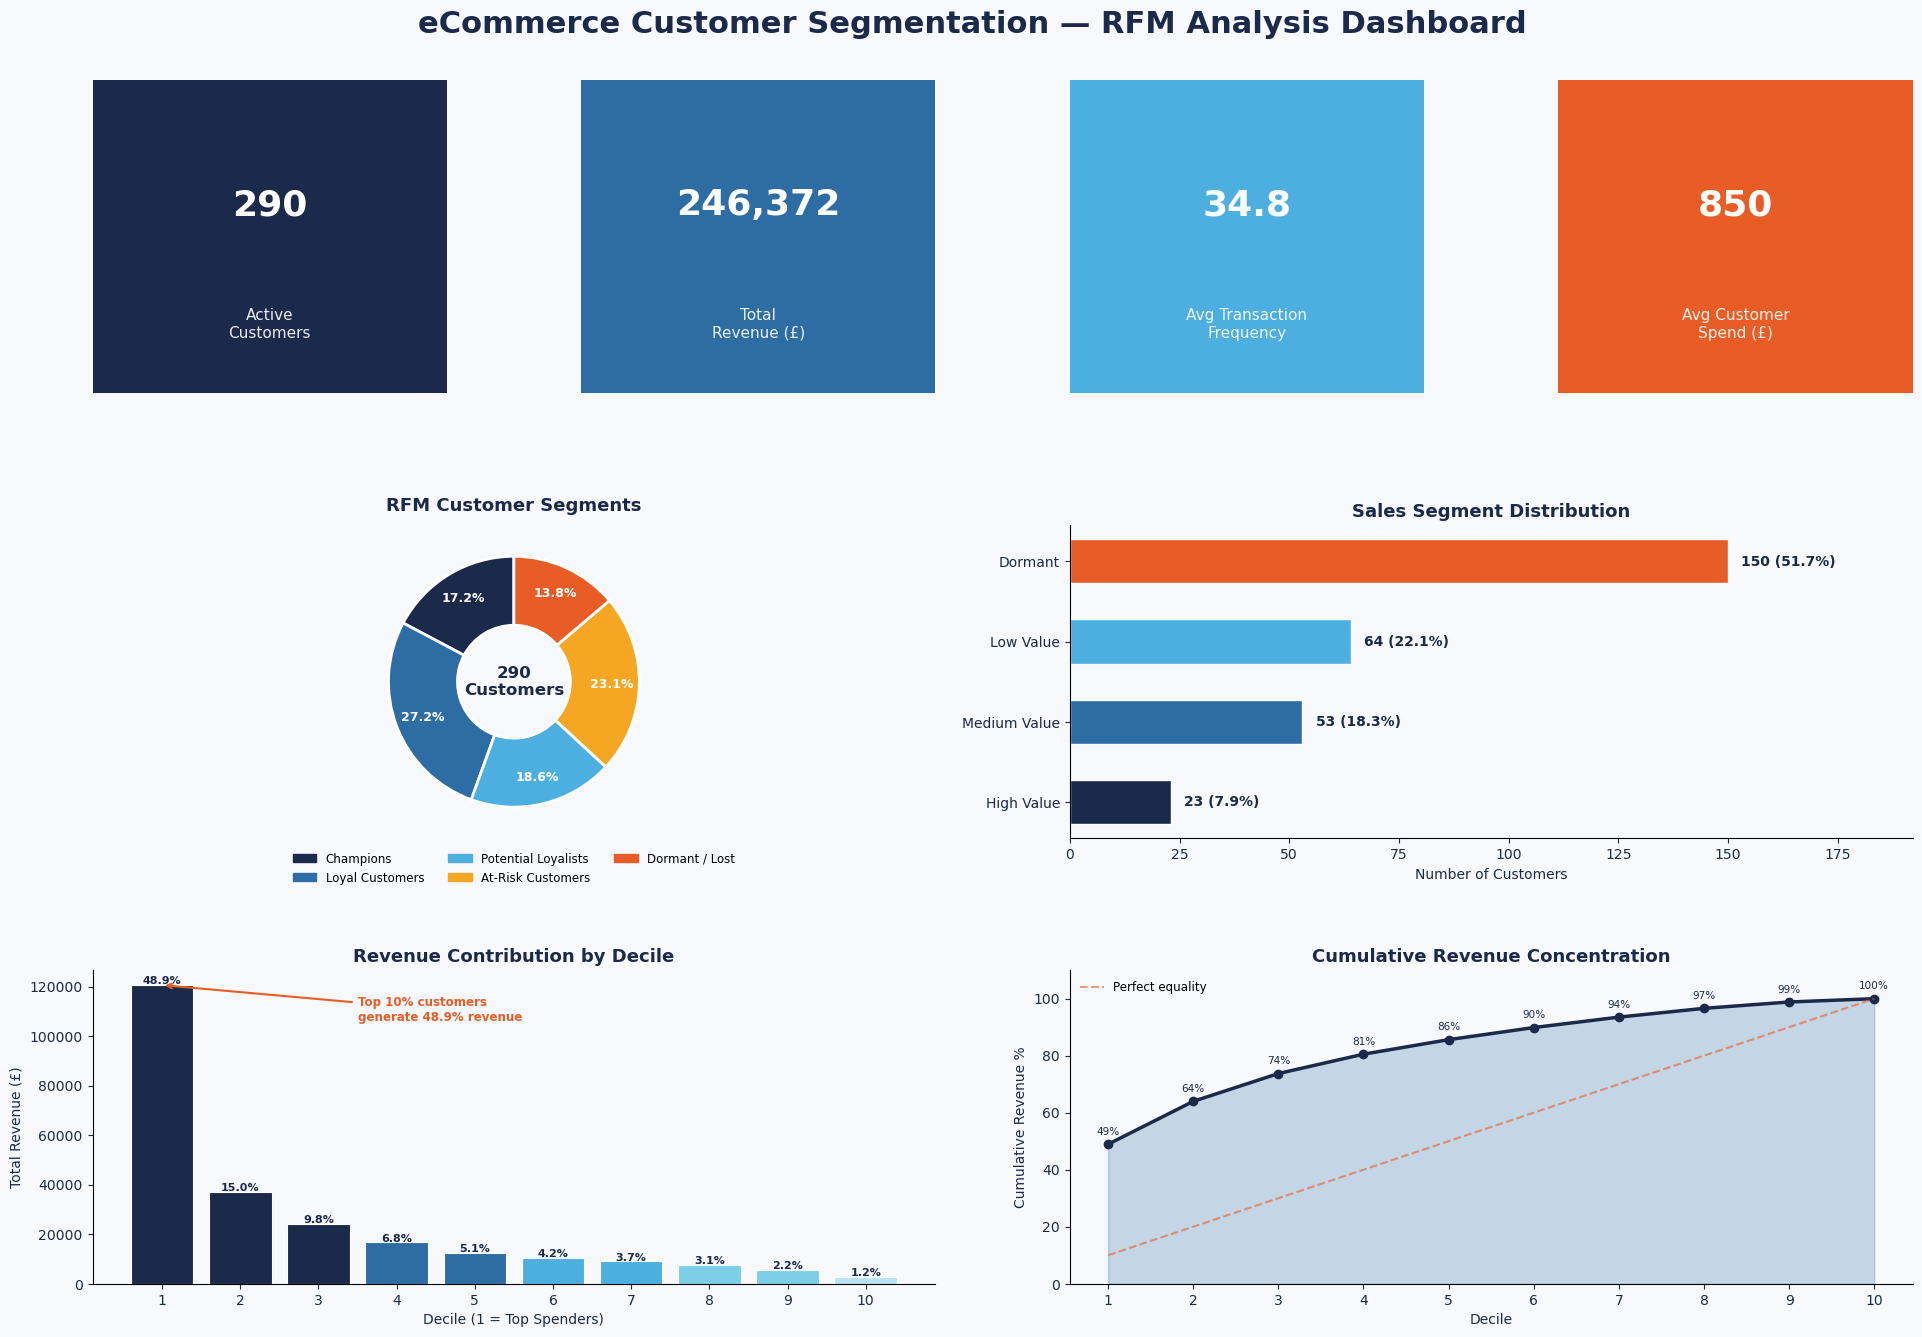

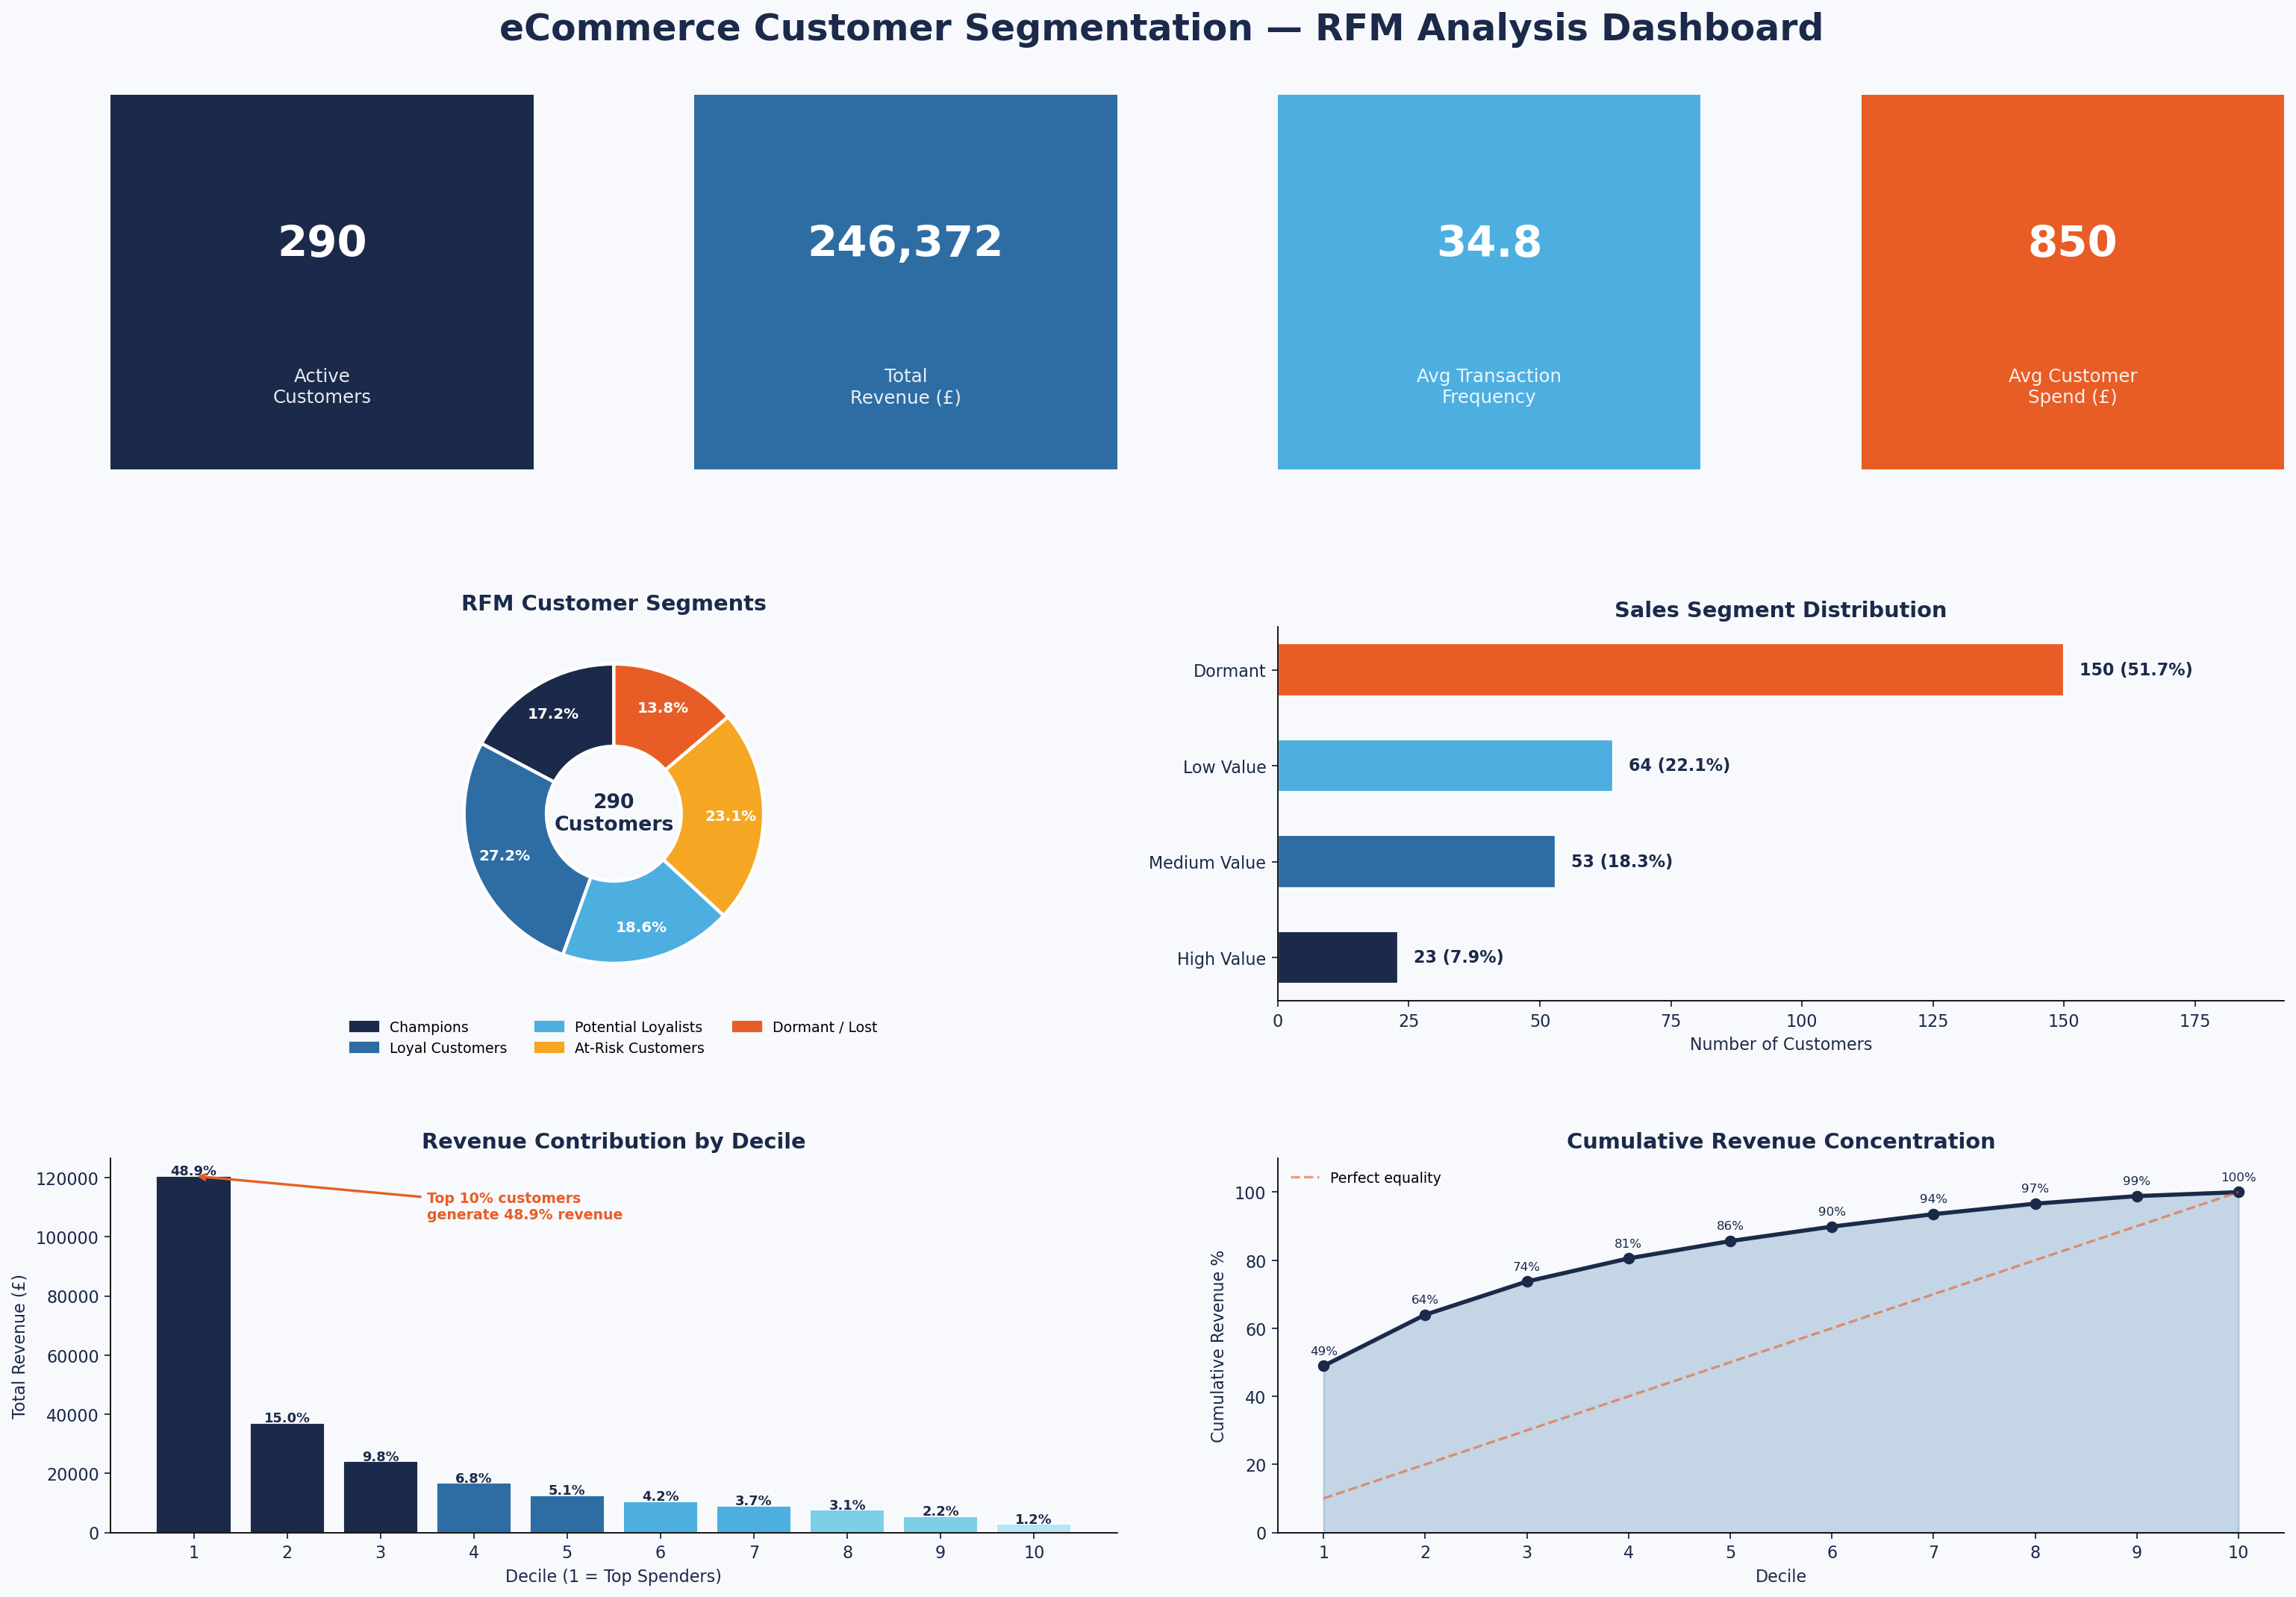

Dashboard 1 saved.


In [68]:
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('eCommerce Customer Segmentation — RFM Analysis Dashboard',
             fontsize=22, fontweight='bold', color=C1, y=0.98)
gs = GridSpec(3, 4, figure=fig, hspace=0.42, wspace=0.38,
              left=0.06, right=0.97, top=0.93, bottom=0.07)

kpis = [
    (f'{len(df_rfm)}', 'Active\nCustomers', C1),
    (f'{df_rfm["Monetary"].sum():,.0f}', 'Total\nRevenue (£)', C2),
    (f'{df_rfm["Frequency"].mean():.1f}', 'Avg Transaction\nFrequency', C3),
    (f'{df_rfm["Monetary"].mean():,.0f}', 'Avg Customer\nSpend (£)', ACC),
]
for i, (val, label, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.text(0.5, 0.60, val, transform=ax.transAxes, fontsize=26,
            fontweight='bold', color='white', ha='center', va='center')
    ax.text(0.5, 0.22, label, transform=ax.transAxes, fontsize=11,
            color='white', ha='center', va='center', alpha=0.9)

ax2 = fig.add_subplot(gs[1, 0:2])
seg_vals = [df_rfm['Segment'].value_counts().get(s, 0) for s in seg_order]
colors_seg = [SEG_COLORS[s] for s in seg_order]
wedges, texts, autotexts = ax2.pie(seg_vals, labels=None, colors=colors_seg,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
ax2.legend([mpatches.Patch(color=SEG_COLORS[s]) for s in seg_order], seg_order,
           loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8.5, framealpha=0)
ax2.set_title('RFM Customer Segments', fontweight='bold', color=C1, fontsize=13, pad=10)
ax2.text(0, 0, f'{len(df_rfm)}\nCustomers', ha='center', va='center',
         fontsize=12, fontweight='bold', color=C1)

ax3 = fig.add_subplot(gs[1, 2:4])
seg_labels = ['High Value','Medium Value','Low Value','Dormant']
seg_cnts = [df_rfm['SalesSegment'].value_counts().get(s, 0) for s in seg_labels]
seg_pct = [c/sum(seg_cnts)*100 for c in seg_cnts]
bars = ax3.barh(seg_labels, seg_cnts, color=[SALE_COLORS[s] for s in seg_labels],
                 height=0.55, edgecolor='white')
for bar, cnt, pct in zip(bars, seg_cnts, seg_pct):
    ax3.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
              f'{cnt} ({pct:.1f}%)', va='center', fontsize=10, color=C1, fontweight='bold')
ax3.set_facecolor(BG); ax3.set_xlabel('Number of Customers', color=C1)
ax3.set_title('Sales Segment Distribution', fontweight='bold', color=C1, fontsize=13)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
ax3.tick_params(colors=C1); ax3.set_xlim(0, max(seg_cnts)*1.28)

ax4 = fig.add_subplot(gs[2, 0:2])
dec_colors = [C1 if i<3 else (C2 if i<5 else (C3 if i<7 else (C4 if i<9 else C5))) for i in range(10)]
bars4 = ax4.bar(decile_summary['Decile'], decile_summary['TotalRevenue'],
                color=dec_colors, edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars4, decile_summary['RevenuePct']):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
             f'{pct:.1f}%', ha='center', fontsize=8, color=C1, fontweight='bold')
ax4.set_facecolor(BG); ax4.set_xlabel('Decile (1 = Top Spenders)', color=C1)
ax4.set_ylabel('Total Revenue (£)', color=C1)
ax4.set_title('Revenue Contribution by Decile', fontweight='bold', color=C1, fontsize=13)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
ax4.set_xticks(range(1,11)); ax4.tick_params(colors=C1)
ax4.annotate(f"Top 10% customers\ngenerate {decile_summary.loc[0,'RevenuePct']:.1f}% revenue",
             xy=(1, decile_summary.loc[0,'TotalRevenue']),
             xytext=(3.5, decile_summary.loc[0,'TotalRevenue']*0.88),
             arrowprops=dict(arrowstyle='->', color=ACC, lw=1.5),
             fontsize=8.5, color=ACC, fontweight='bold')

ax5 = fig.add_subplot(gs[2, 2:4])
cum_pct = decile_summary['CumRevenuePct'].values
x_vals = np.arange(1, 11)
ax5.fill_between(x_vals, cum_pct, alpha=0.25, color=C2)
ax5.plot(x_vals, cum_pct, color=C1, linewidth=2.5, marker='o', markersize=6)
ax5.plot([1,10], [10,100], '--', color=ACC, alpha=0.6, linewidth=1.5, label='Perfect equality')
for x, y in zip(x_vals, cum_pct):
    ax5.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                 xytext=(0, 7), ha='center', fontsize=7.5, color=C1)
ax5.set_facecolor(BG); ax5.set_xlabel('Decile', color=C1)
ax5.set_ylabel('Cumulative Revenue %', color=C1)
ax5.set_title('Cumulative Revenue Concentration', fontweight='bold', color=C1, fontsize=13)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)
ax5.set_xticks(range(1, 11)); ax5.set_ylim(0, 110); ax5.tick_params(colors=C1)
ax5.legend(fontsize=8.5, framealpha=0)

plt.savefig(f'{OUT}/rfm_dashboard_1.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
display(Image(filename=f'{OUT}/rfm_dashboard_1.png'))
print("Dashboard 1 saved.")

# 
#  FIGURE 2: RFM SCORE HEATMAP + FREQ/MONETARY
# 

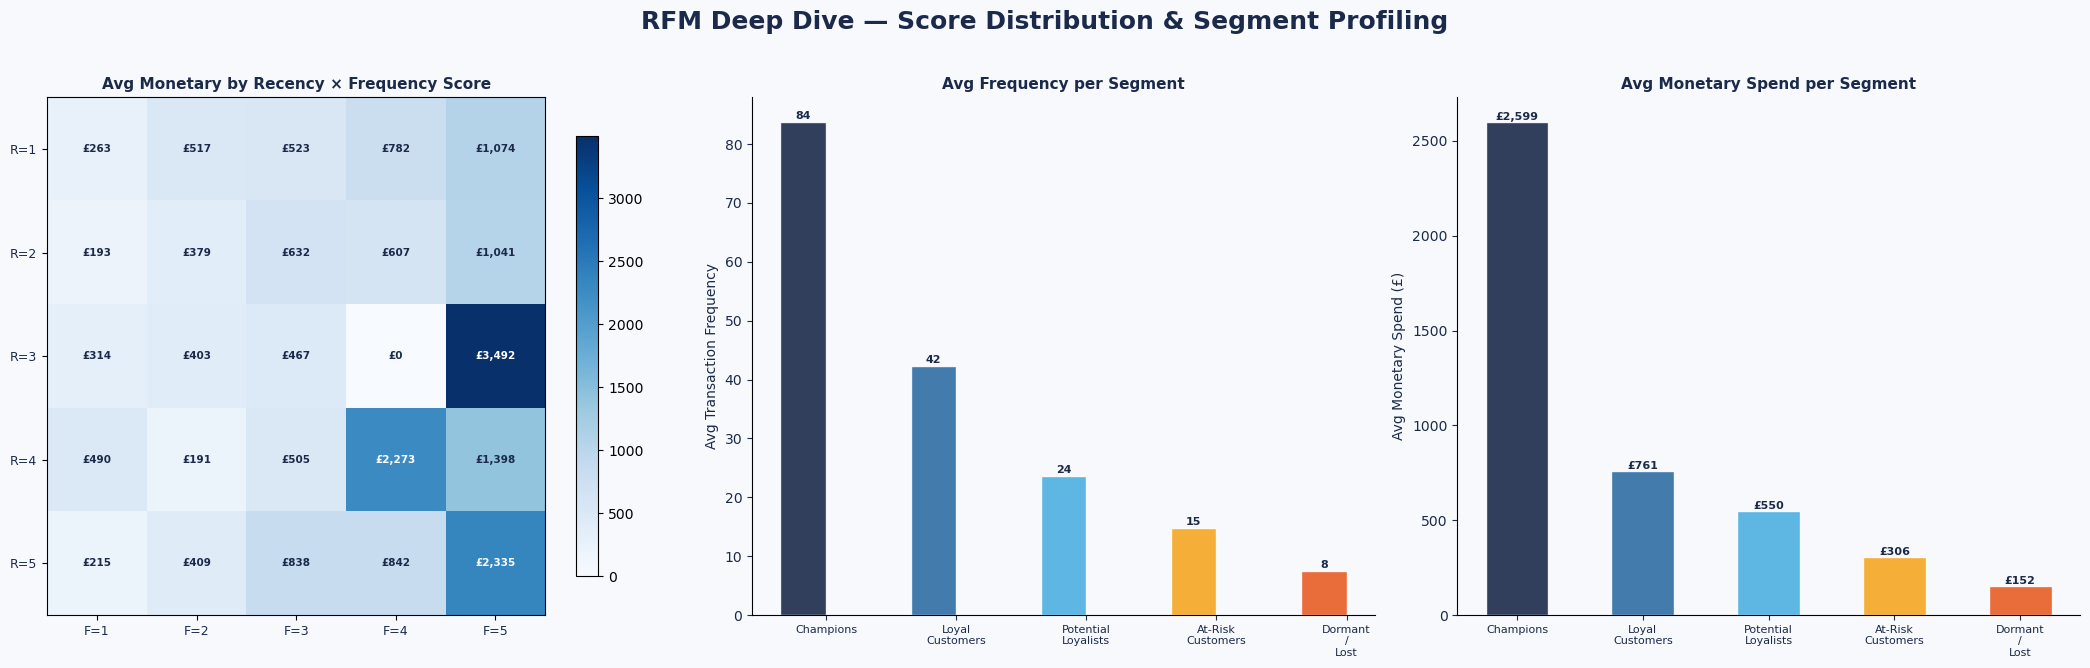

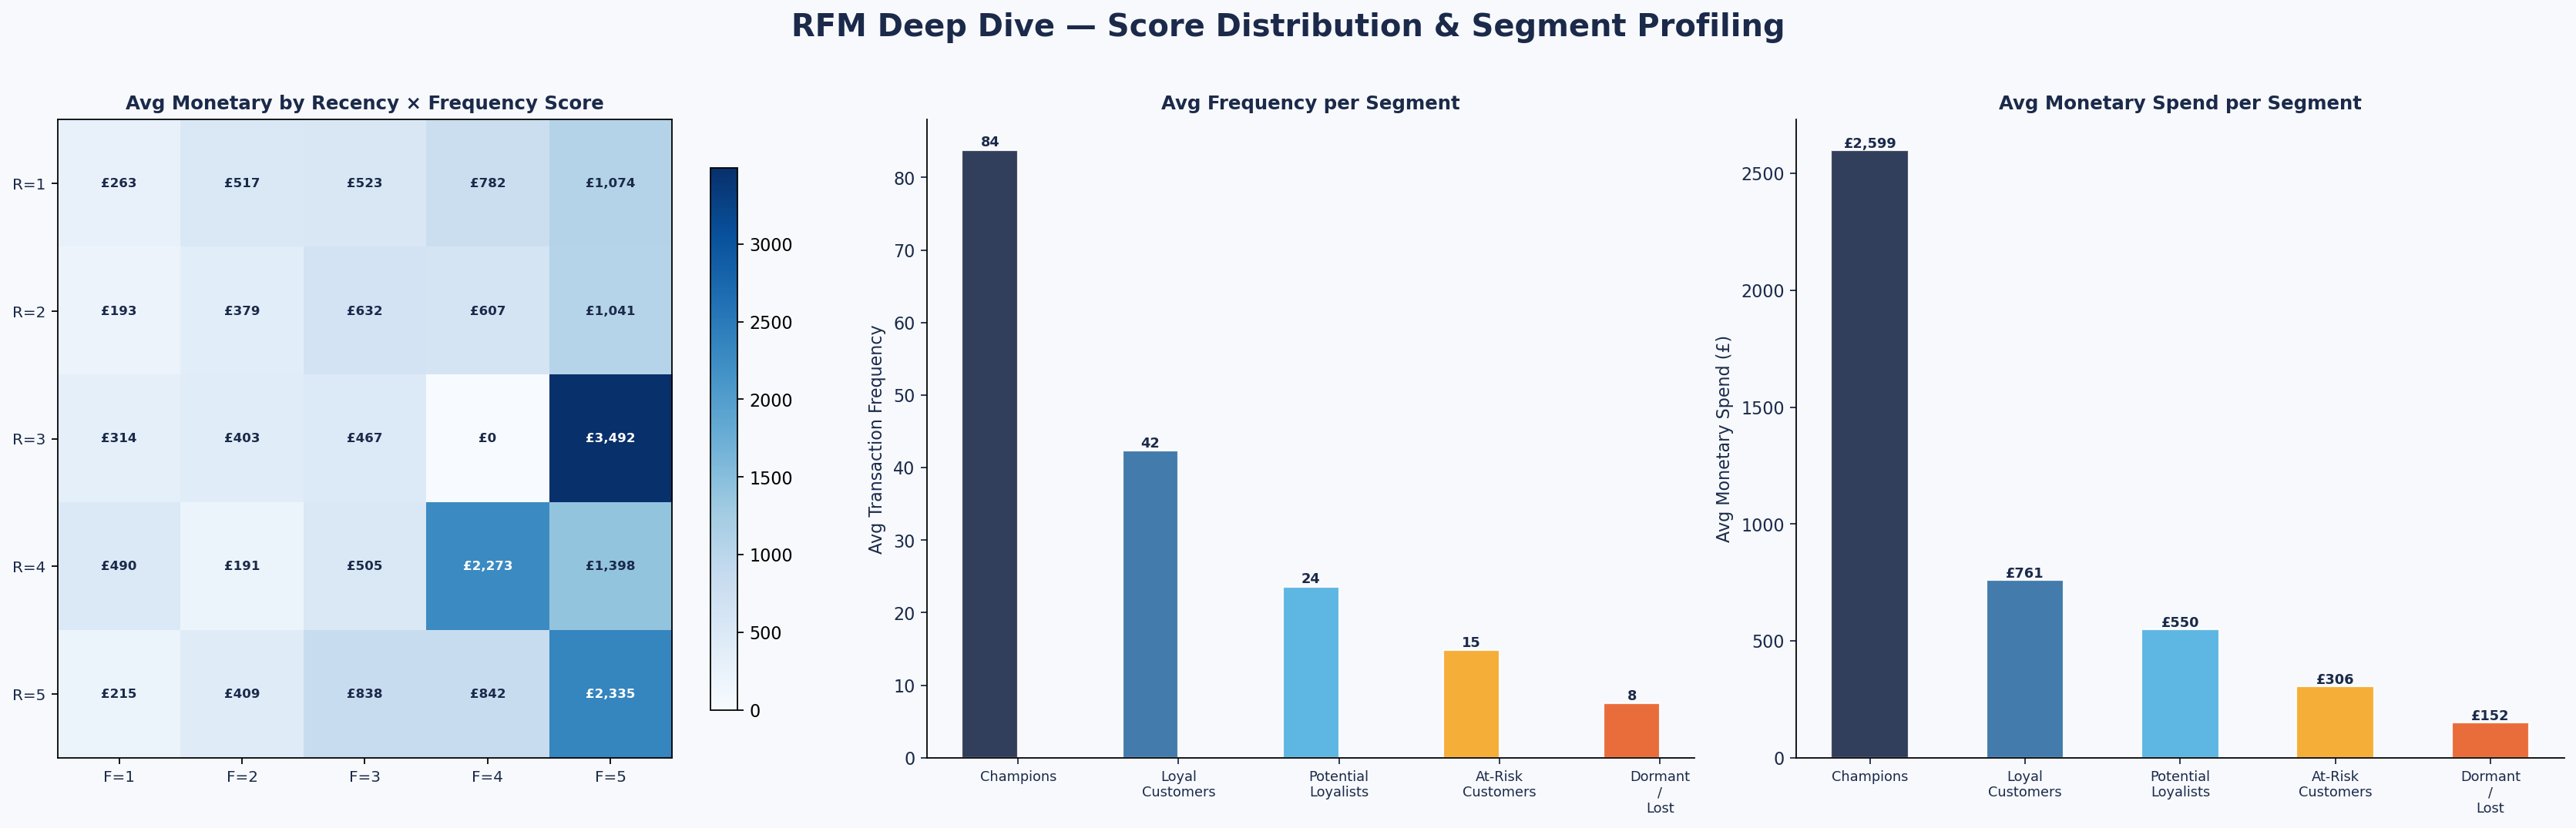

Dashboard 2 saved.


In [69]:
fig2, axes = plt.subplots(1, 3, figsize=(21, 6.5), facecolor=BG)
fig2.suptitle('RFM Deep Dive — Score Distribution & Segment Profiling',
              fontsize=18, fontweight='bold', color=C1, y=1.02)

ax = axes[0]
heat_data = df_rfm.groupby(['R_Score','F_Score'])['Monetary'].mean().unstack(fill_value=0)
im = ax.imshow(heat_data.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(heat_data.columns))); ax.set_yticks(range(len(heat_data.index)))
ax.set_xticklabels([f'F={c}' for c in heat_data.columns], fontsize=9, color=C1)
ax.set_yticklabels([f'R={r}' for r in heat_data.index], fontsize=9, color=C1)
ax.set_title('Avg Monetary by Recency × Frequency Score', fontweight='bold', color=C1, fontsize=11)
for i in range(len(heat_data.index)):
    for j in range(len(heat_data.columns)):
        val = heat_data.values[i, j]
        ax.text(j, i, f'£{val:,.0f}', ha='center', va='center',
                fontsize=7.5, color='white' if val > 1500 else C1, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.85)

ax2f = axes[1]
seg_means_f = [df_rfm[df_rfm['Segment']==s]['Frequency'].mean() for s in seg_order]
seg_means_m = [df_rfm[df_rfm['Segment']==s]['Monetary'].mean() for s in seg_order]
x = np.arange(len(seg_order)); w = 0.35
bars_f = ax2f.bar(x - w/2, seg_means_f, w, color=[SEG_COLORS[s] for s in seg_order],
                   alpha=0.9, label='Avg Frequency', edgecolor='white')
ax2f.set_facecolor(BG); ax2f.set_xticks(x)
ax2f.set_xticklabels([s.replace(' ','\n') for s in seg_order], fontsize=8, color=C1)
ax2f.set_ylabel('Avg Transaction Frequency', color=C1)
ax2f.set_title('Avg Frequency per Segment', fontweight='bold', color=C1, fontsize=11)
ax2f.spines['top'].set_visible(False); ax2f.spines['right'].set_visible(False)
ax2f.tick_params(colors=C1)
for bar, v in zip(bars_f, seg_means_f):
    ax2f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f'{v:.0f}', ha='center', fontsize=8, color=C1, fontweight='bold')

ax2m = axes[2]
bars_m = ax2m.bar(x, seg_means_m, 0.5, color=[SEG_COLORS[s] for s in seg_order],
                   alpha=0.9, edgecolor='white')
ax2m.set_facecolor(BG); ax2m.set_xticks(x)
ax2m.set_xticklabels([s.replace(' ','\n') for s in seg_order], fontsize=8, color=C1)
ax2m.set_ylabel('Avg Monetary Spend (£)', color=C1)
ax2m.set_title('Avg Monetary Spend per Segment', fontweight='bold', color=C1, fontsize=11)
ax2m.spines['top'].set_visible(False); ax2m.spines['right'].set_visible(False)
ax2m.tick_params(colors=C1)
for bar, v in zip(bars_m, seg_means_m):
    ax2m.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
              f'£{v:,.0f}', ha='center', fontsize=8, color=C1, fontweight='bold')

fig2.set_facecolor(BG)
plt.tight_layout()
plt.savefig(f'{OUT}/rfm_dashboard_2.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
display(Image(filename=f'{OUT}/rfm_dashboard_2.png'))
print("Dashboard 2 saved.")

# 
# SPLIT 3 — FIGURE 3: DECILE TABLE + COUNTRY + STRATEGY
#

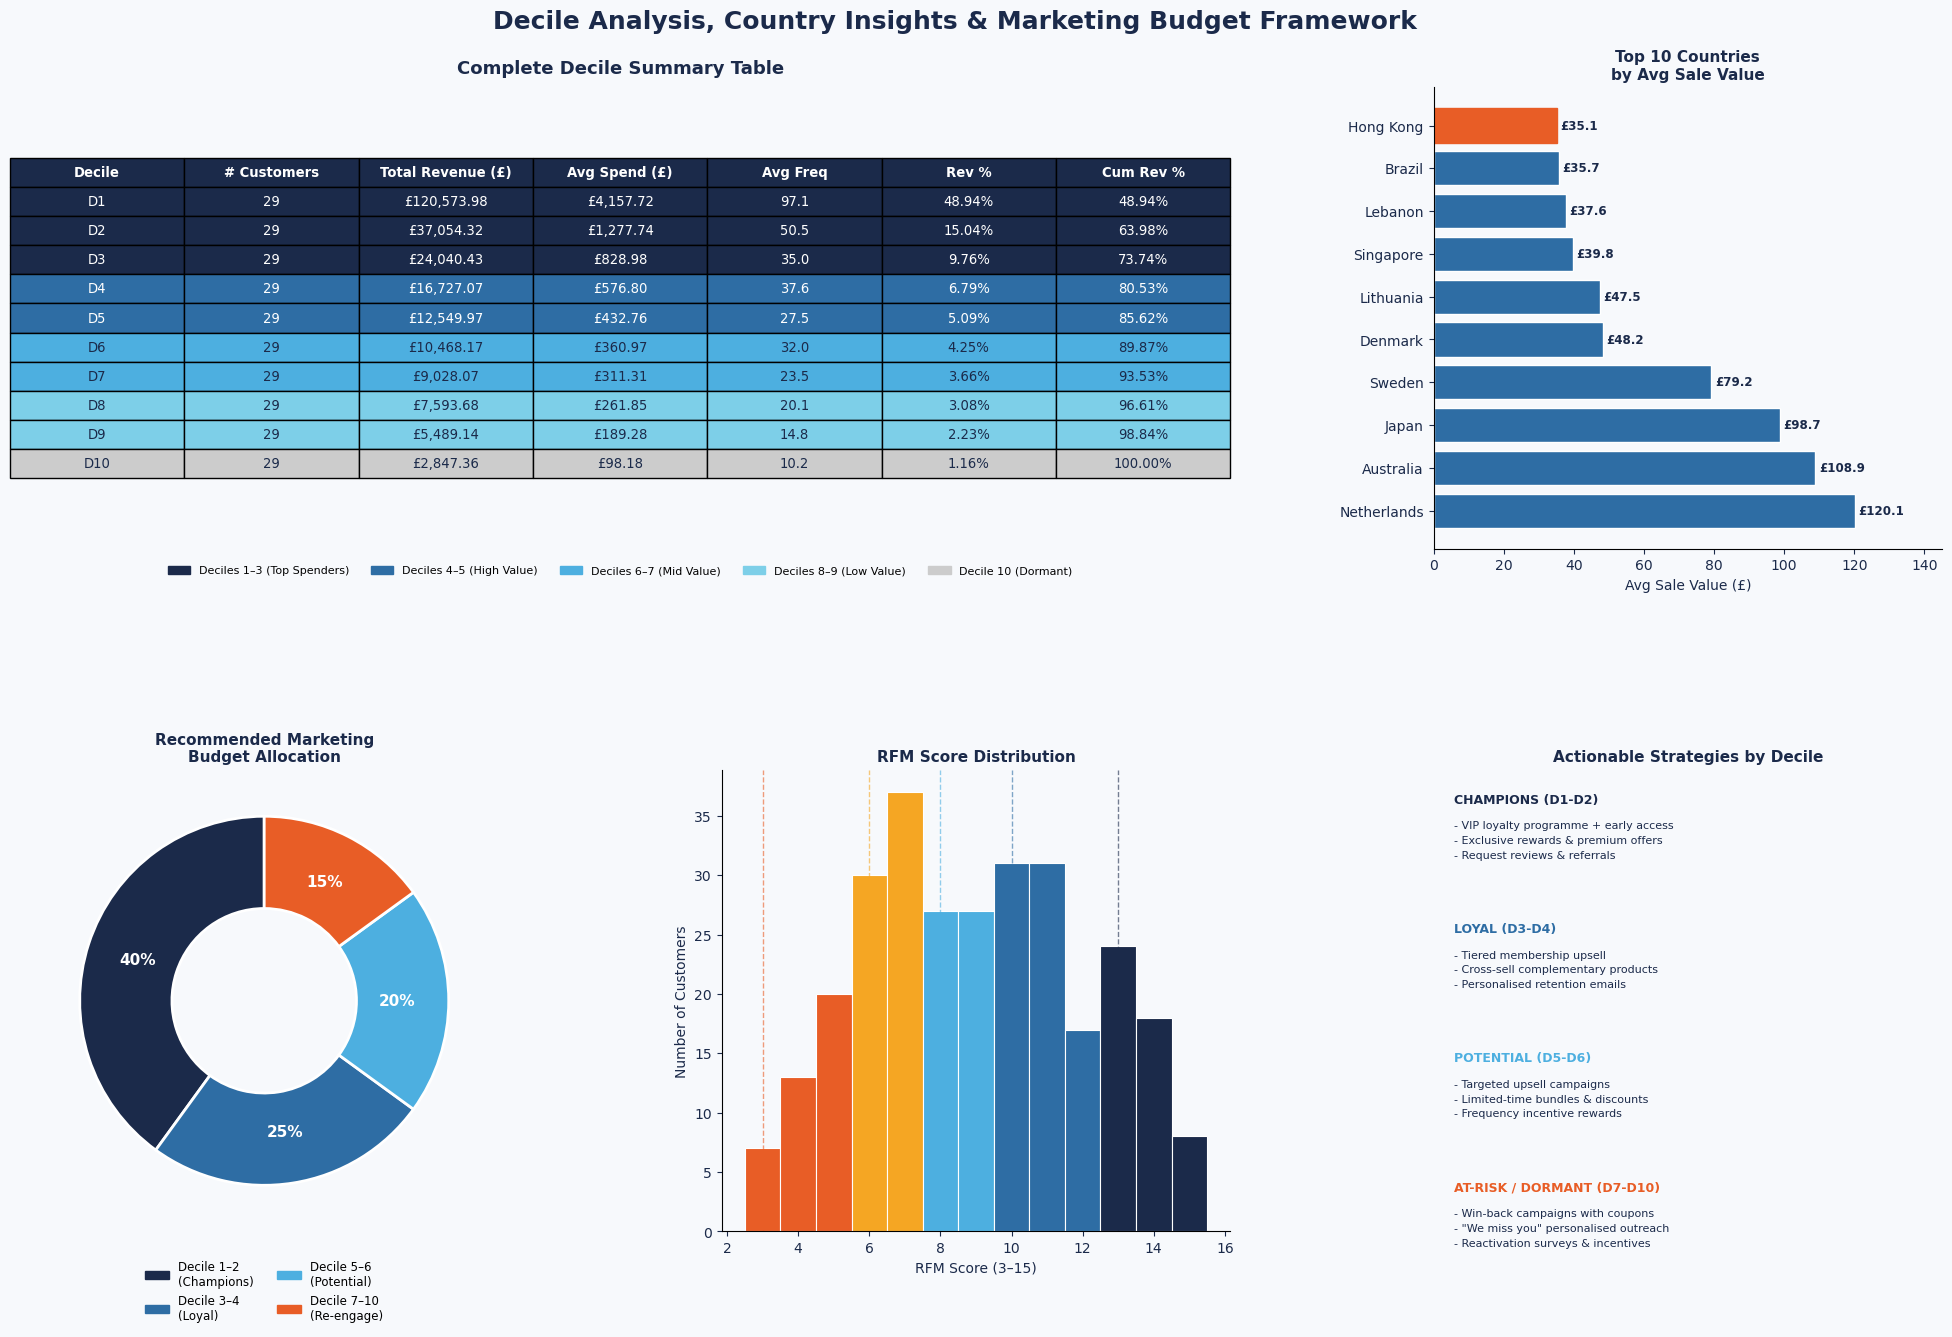

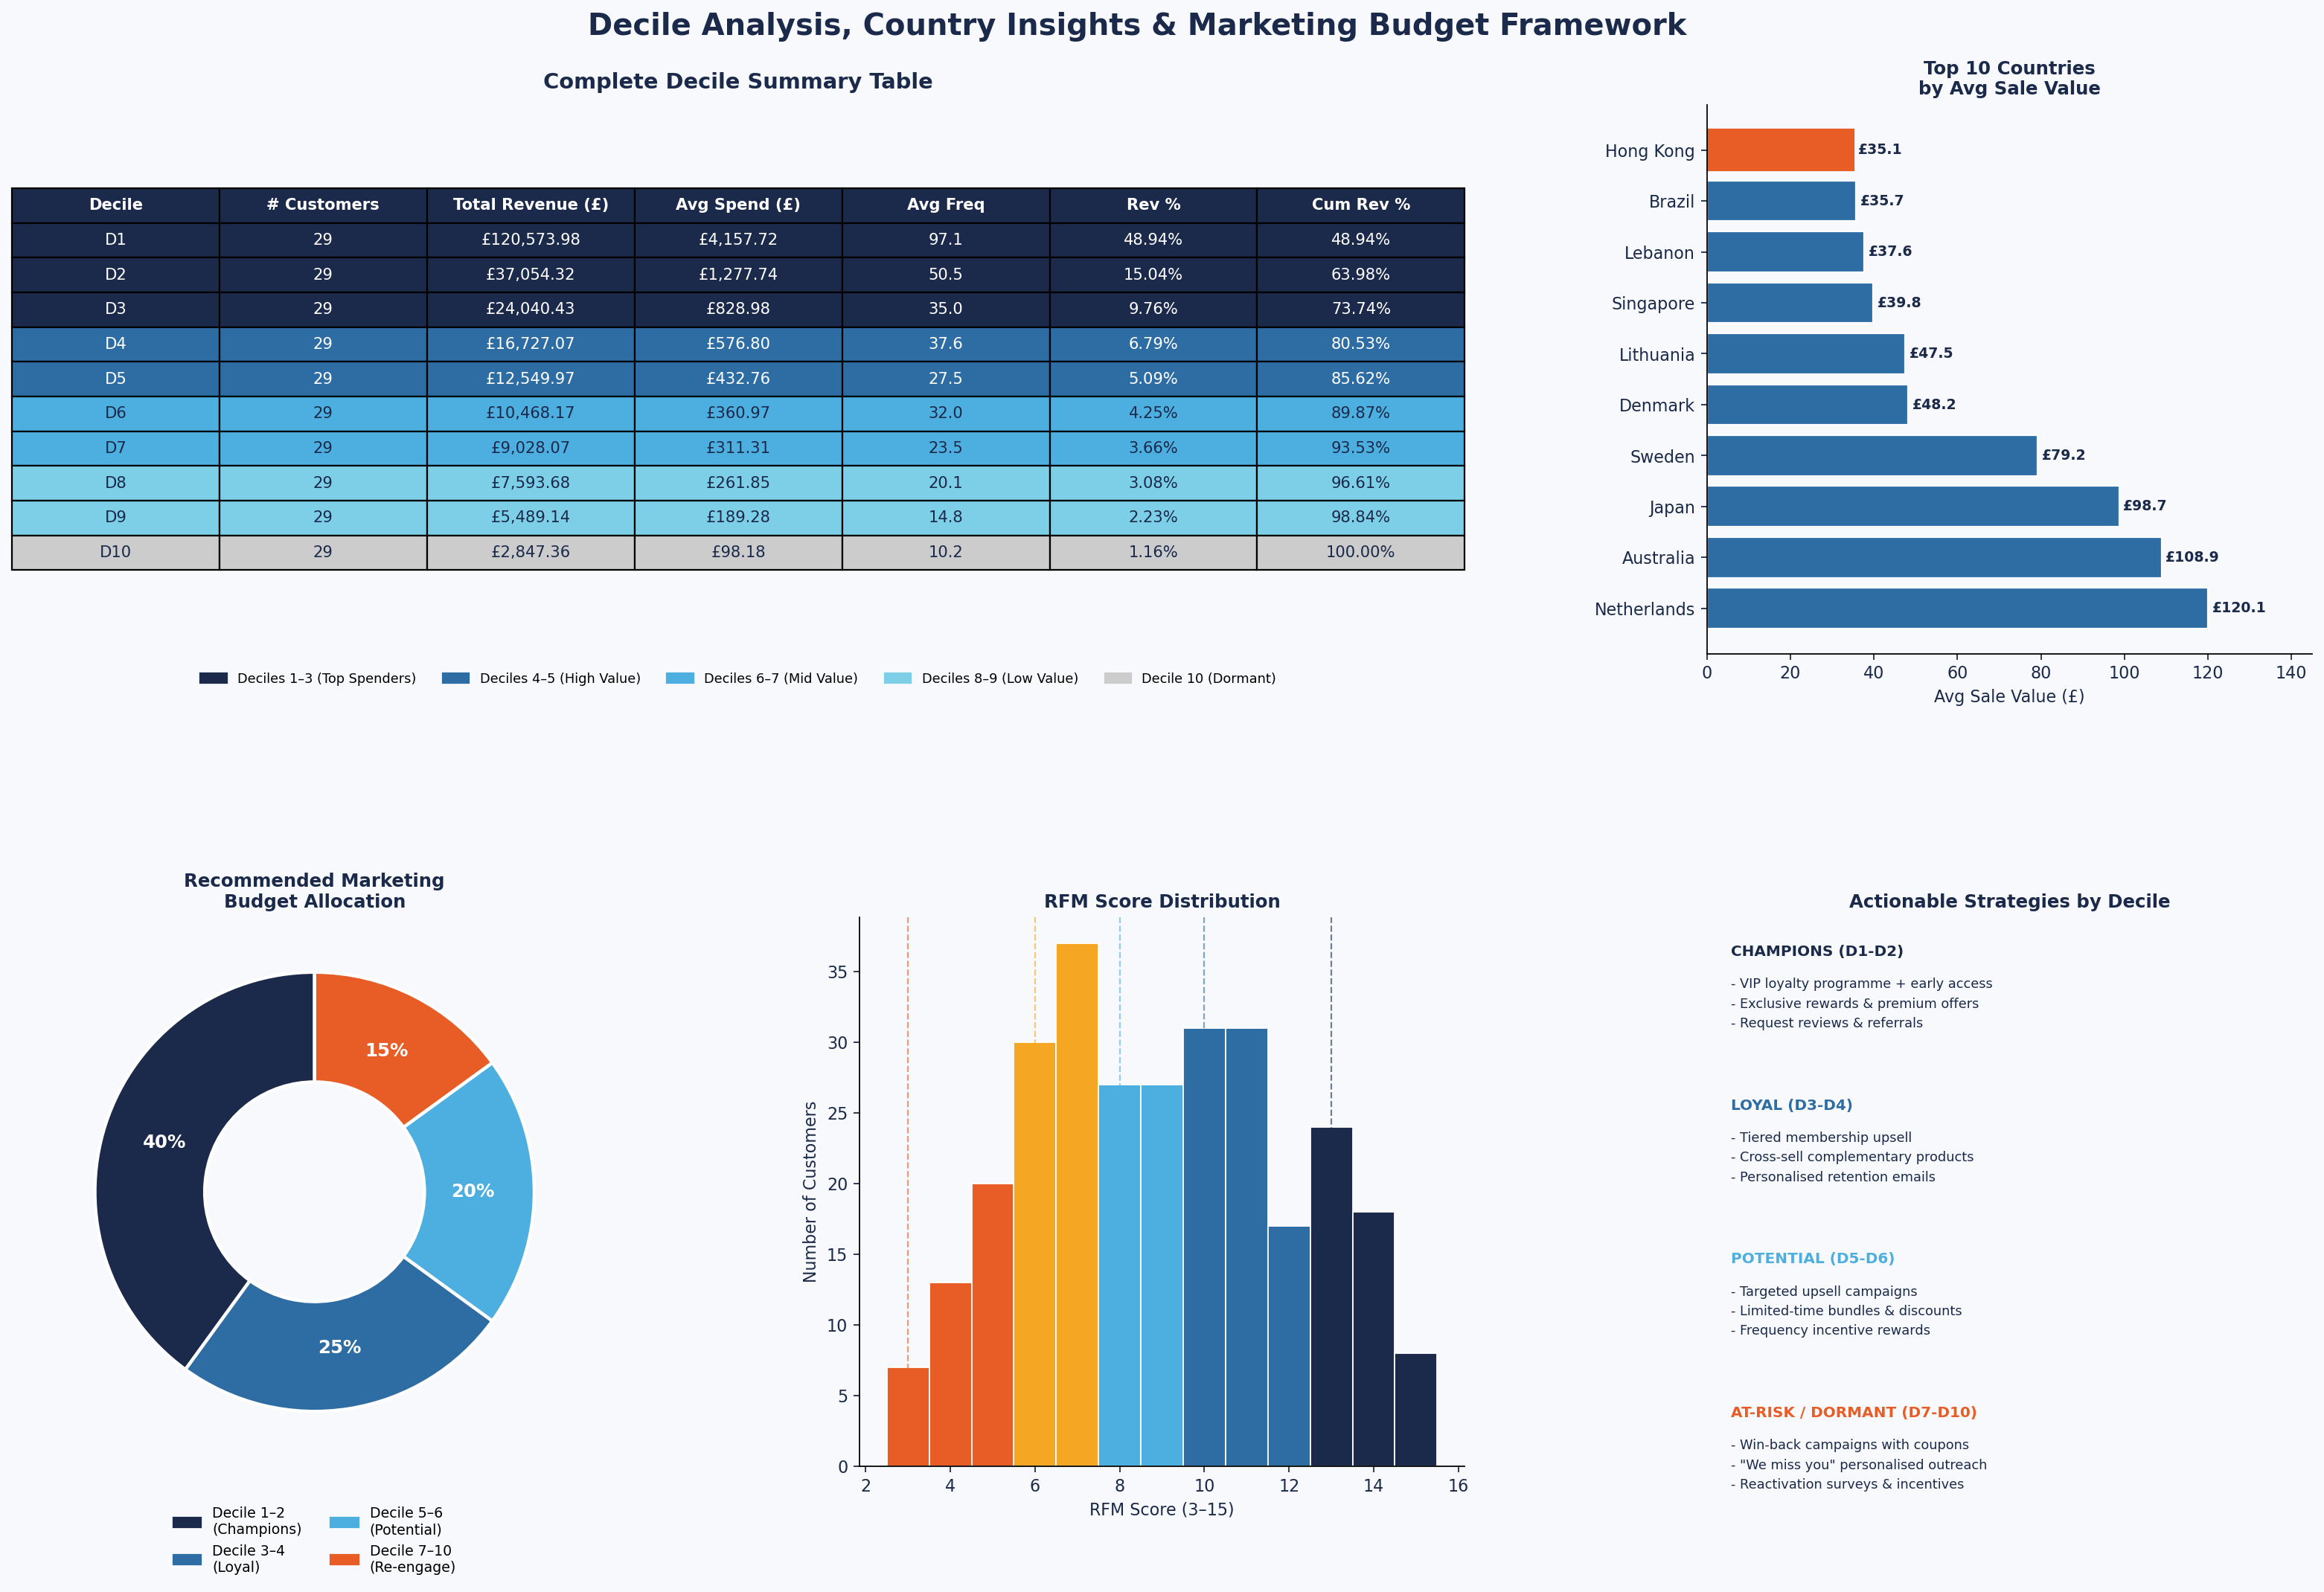

Dashboard 3 saved.


In [70]:
fig3 = plt.figure(figsize=(21, 13), facecolor=BG)
fig3.suptitle('Decile Analysis, Country Insights & Marketing Budget Framework',
              fontsize=18, fontweight='bold', color=C1, y=0.99)
gs3 = GridSpec(2, 3, figure=fig3, hspace=0.48, wspace=0.4,
               left=0.05, right=0.97, top=0.93, bottom=0.05)

ax_tbl = fig3.add_subplot(gs3[0, 0:2])
ax_tbl.set_facecolor(BG); ax_tbl.axis('off')
tbl_cols = ['Decile','# Customers','Total Revenue (£)','Avg Spend (£)','Avg Freq','Rev %','Cum Rev %']
tbl_rows = []
for _, r in decile_summary.iterrows():
    tbl_rows.append([
        f"D{int(r['Decile'])}", str(int(r['CustomerCount'])),
        f"£{r['TotalRevenue']:,.2f}", f"£{r['AvgMonetary']:,.2f}",
        f"{r['AvgFrequency']:.1f}", f"{r['RevenuePct']:.2f}%", f"{r['CumRevenuePct']:.2f}%",
    ])
row_colors = []
for i in range(10):
    if i < 3: c = [C1]*7
    elif i < 5: c = [C2]*7
    elif i < 7: c = [C3]*7
    elif i < 9: c = [C4]*7
    else: c = ['#CCCCCC']*7
    row_colors.append(c)

tbl = ax_tbl.table(cellText=tbl_rows, colLabels=tbl_cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 1.75)
for j in range(len(tbl_cols)):
    tbl[0,j].set_facecolor(C1); tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, row_c in enumerate(row_colors, start=1):
    for j, clr in enumerate(row_c):
        tbl[i,j].set_facecolor(clr)
        tbl[i,j].set_text_props(color='white' if i<6 else C1)
ax_tbl.set_title('Complete Decile Summary Table', fontweight='bold', color=C1, fontsize=13, pad=10)
leg_patches = [
    mpatches.Patch(color=C1, label='Deciles 1–3 (Top Spenders)'),
    mpatches.Patch(color=C2, label='Deciles 4–5 (High Value)'),
    mpatches.Patch(color=C3, label='Deciles 6–7 (Mid Value)'),
    mpatches.Patch(color=C4, label='Deciles 8–9 (Low Value)'),
    mpatches.Patch(color='#CCCCCC', label='Decile 10 (Dormant)'),
]
ax_tbl.legend(handles=leg_patches, loc='lower center', bbox_to_anchor=(0.5,-0.08),
              ncol=5, fontsize=8, framealpha=0)

ax_cty = fig3.add_subplot(gs3[0, 2])
top10_cty = df_country.nlargest(10, 'AvgSales')
bars_cty = ax_cty.barh(top10_cty['Country'], top10_cty['AvgSales'], color=C2, edgecolor='white')
bars_cty[-1].set_color(ACC)
for bar, val in zip(bars_cty, top10_cty['AvgSales']):
    ax_cty.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                f'£{val:.1f}', va='center', fontsize=8.5, color=C1, fontweight='bold')
ax_cty.set_facecolor(BG); ax_cty.set_xlabel('Avg Sale Value (£)', color=C1)
ax_cty.set_title('Top 10 Countries\nby Avg Sale Value', fontweight='bold', color=C1, fontsize=11)
ax_cty.spines['top'].set_visible(False); ax_cty.spines['right'].set_visible(False)
ax_cty.tick_params(colors=C1); ax_cty.set_xlim(0, 145)

ax_bud = fig3.add_subplot(gs3[1, 0])
budget_labels = ['Decile 1–2\n(Champions)','Decile 3–4\n(Loyal)','Decile 5–6\n(Potential)','Decile 7–10\n(Re-engage)']
budget_pcts = [40, 25, 20, 15]
budget_colors = [C1, C2, C3, ACC]
wedges, texts, autotexts = ax_bud.pie(budget_pcts, colors=budget_colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
ax_bud.legend([mpatches.Patch(color=c) for c in budget_colors], budget_labels,
              loc='lower center', bbox_to_anchor=(0.5,-0.22), ncol=2, fontsize=8.5, framealpha=0)
ax_bud.set_title('Recommended Marketing\nBudget Allocation', fontweight='bold', color=C1, fontsize=11)

ax_hist = fig3.add_subplot(gs3[1, 1])
rfm_scores = df_rfm['RFM_Score']
n, bins, patches = ax_hist.hist(rfm_scores, bins=range(3, 17), color=C3,
                                 edgecolor='white', linewidth=0.8, align='left')
for patch, left in zip(patches, bins):
    if left >= 13: patch.set_facecolor(SEG_COLORS['Champions'])
    elif left >= 10: patch.set_facecolor(SEG_COLORS['Loyal Customers'])
    elif left >= 8: patch.set_facecolor(SEG_COLORS['Potential Loyalists'])
    elif left >= 6: patch.set_facecolor(SEG_COLORS['At-Risk Customers'])
    else: patch.set_facecolor(SEG_COLORS['Dormant / Lost'])
ax_hist.set_facecolor(BG); ax_hist.set_xlabel('RFM Score (3–15)', color=C1)
ax_hist.set_ylabel('Number of Customers', color=C1)
ax_hist.set_title('RFM Score Distribution', fontweight='bold', color=C1, fontsize=11)
ax_hist.spines['top'].set_visible(False); ax_hist.spines['right'].set_visible(False)
ax_hist.tick_params(colors=C1)
for thresh, lbl, col in [(3,'Dormant',SEG_COLORS['Dormant / Lost']),
                          (6,'At-Risk',SEG_COLORS['At-Risk Customers']),
                          (8,'Potential',SEG_COLORS['Potential Loyalists']),
                          (10,'Loyal',SEG_COLORS['Loyal Customers']),
                          (13,'Champions',SEG_COLORS['Champions'])]:
    ax_hist.axvline(thresh, color=col, linestyle='--', linewidth=1, alpha=0.6)

ax_rec = fig3.add_subplot(gs3[1, 2])
ax_rec.set_facecolor('#EEF4FB'); ax_rec.axis('off')
strategies = [
    ('CHAMPIONS (D1-D2)', C1, '- VIP loyalty programme + early access\n- Exclusive rewards & premium offers\n- Request reviews & referrals'),
    ('LOYAL (D3-D4)', C2, '- Tiered membership upsell\n- Cross-sell complementary products\n- Personalised retention emails'),
    ('POTENTIAL (D5-D6)', C3, '- Targeted upsell campaigns\n- Limited-time bundles & discounts\n- Frequency incentive rewards'),
    ('AT-RISK / DORMANT (D7-D10)', ACC, '- Win-back campaigns with coupons\n- "We miss you" personalised outreach\n- Reactivation surveys & incentives'),
]
y_pos = 0.95
for title, color, detail in strategies:
    ax_rec.text(0.04, y_pos, title, transform=ax_rec.transAxes, fontsize=9,
                fontweight='bold', color=color, va='top')
    ax_rec.text(0.04, y_pos-0.06, detail, transform=ax_rec.transAxes, fontsize=8,
                color=C1, va='top', linespacing=1.6)
    y_pos -= 0.28
ax_rec.set_title('Actionable Strategies by Decile', fontweight='bold', color=C1, fontsize=11)

plt.savefig(f'{OUT}/rfm_dashboard_3.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
display(Image(filename=f'{OUT}/rfm_dashboard_3.png'))
print("Dashboard 3 saved.")

#
# SPLIT 4 — FIGURE 4: SCATTER FREQUENCY vs MONETARY
# 

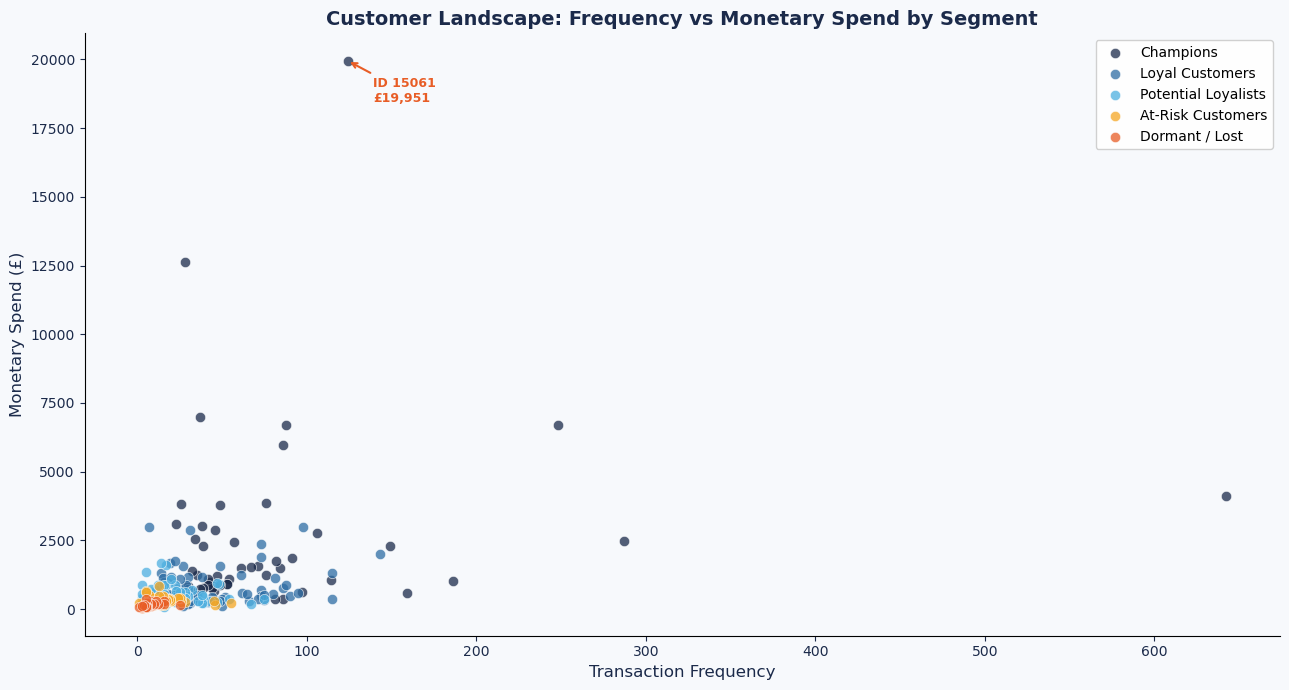

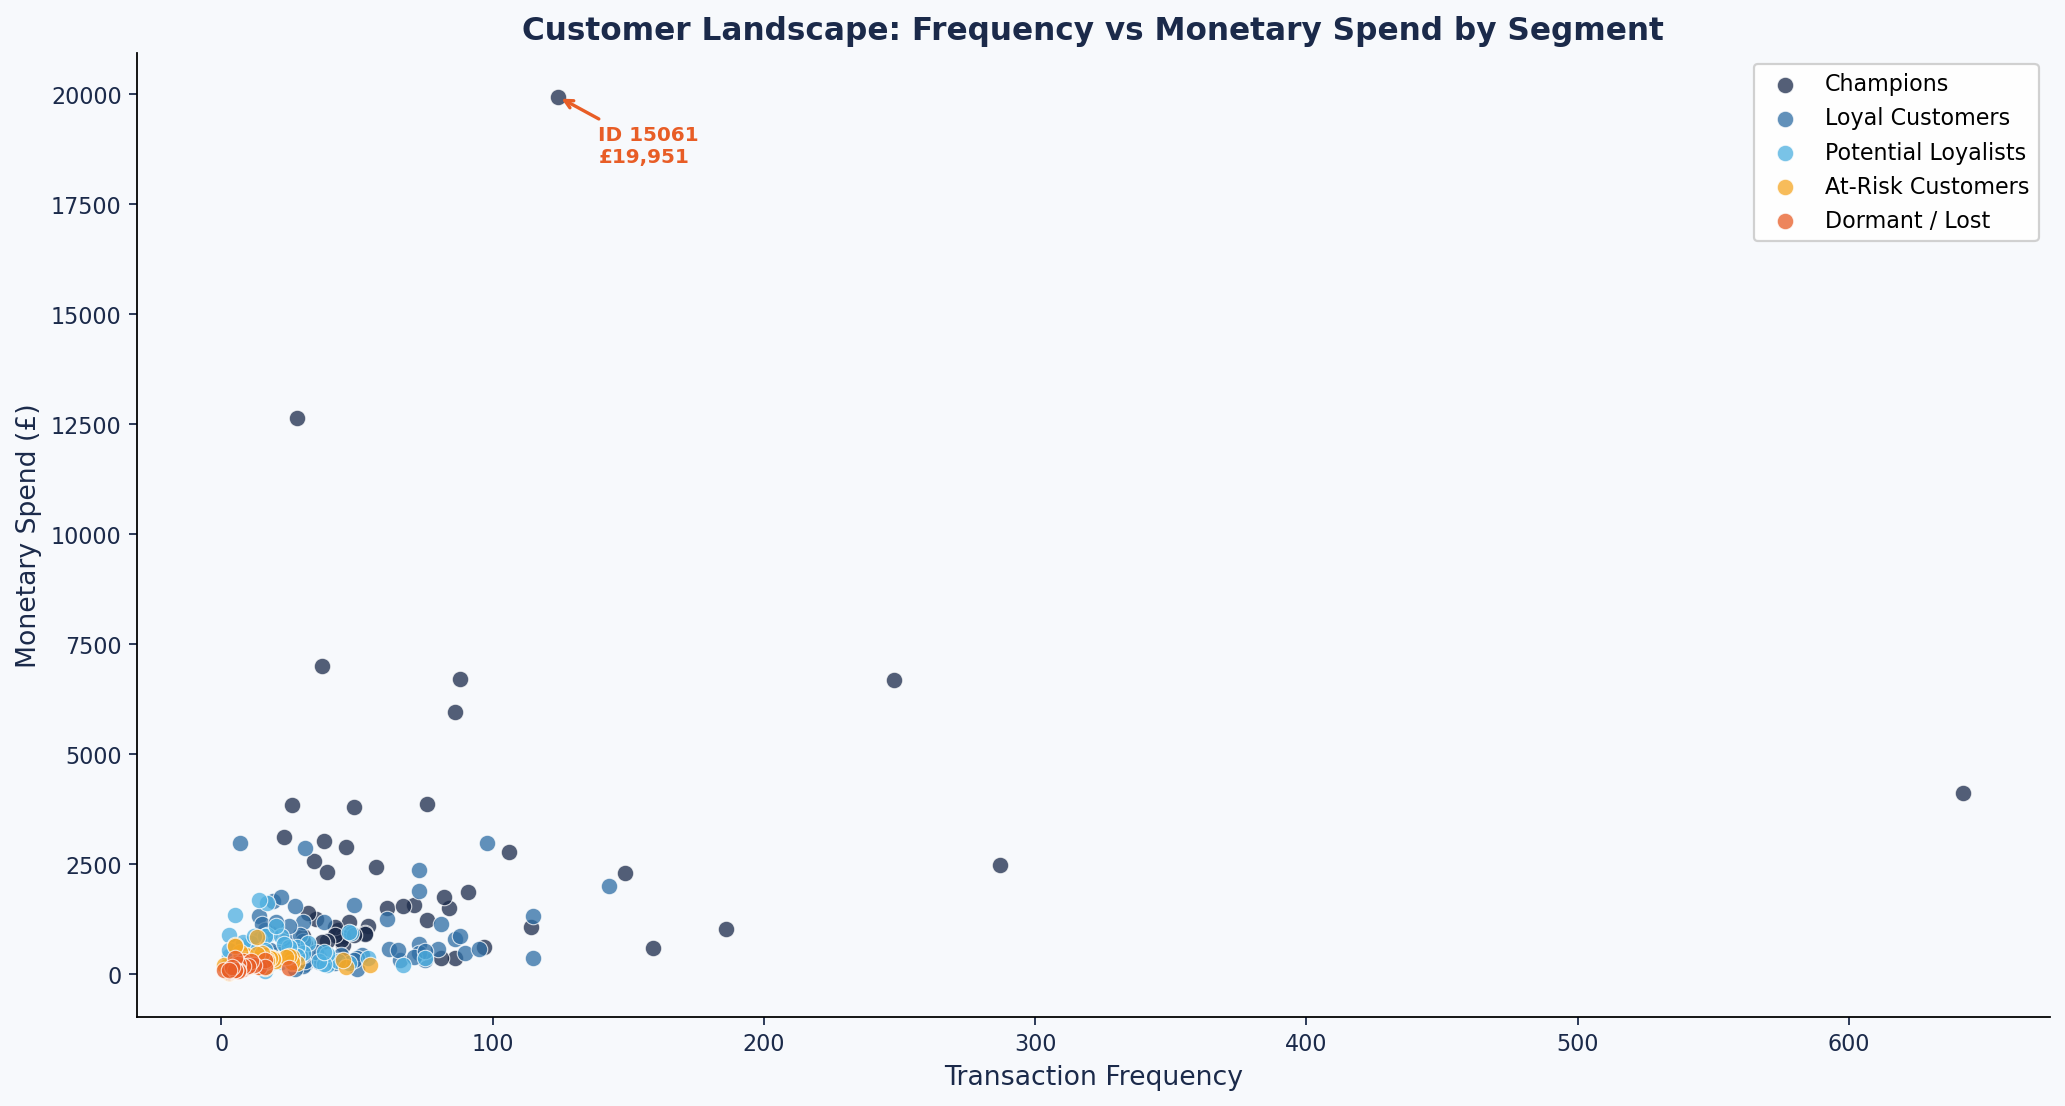

Dashboard 4 saved.


In [71]:
fig4, ax = plt.subplots(figsize=(13, 7), facecolor=BG)
for seg in seg_order:
    sub = df_rfm[df_rfm['Segment']==seg]
    ax.scatter(sub['Frequency'], sub['Monetary'], c=SEG_COLORS[seg],
               label=seg, alpha=0.75, s=55, edgecolors='white', linewidths=0.5)
ax.set_facecolor(BG)
ax.set_xlabel('Transaction Frequency', fontsize=12, color=C1)
ax.set_ylabel('Monetary Spend (£)', fontsize=12, color=C1)
ax.set_title('Customer Landscape: Frequency vs Monetary Spend by Segment',
             fontsize=14, fontweight='bold', color=C1)
ax.legend(fontsize=10, framealpha=0.9, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=C1)

top_cust = df_rfm.nlargest(1,'Monetary').iloc[0]
ax.annotate(f"ID {int(top_cust['CustomerID'])}\n£{top_cust['Monetary']:,.0f}",
            xy=(top_cust['Frequency'], top_cust['Monetary']),
            xytext=(top_cust['Frequency']+15, top_cust['Monetary']-1500),
            arrowprops=dict(arrowstyle='->', color=ACC, lw=1.5),
            fontsize=9, color=ACC, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT}/rfm_dashboard_4.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
display(Image(filename=f'{OUT}/rfm_dashboard_4.png'))
print("Dashboard 4 saved.")

# 
#  5 — EXCEL EXPORT
#

In [72]:
with pd.ExcelWriter(f'{OUT}/RFM_Analysis_Report.xlsx', engine='openpyxl') as writer:
    df_rfm[['CustomerID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score',
            'RFM_Score','Segment','SalesSegment']].to_excel(writer, sheet_name='RFM_Full', index=False)
    decile_summary.to_excel(writer, sheet_name='Decile_Summary', index=False)
    df_rfm.groupby('Segment').agg(
        Count=('CustomerID','count'), AvgRecency=('Recency','mean'),
        AvgFrequency=('Frequency','mean'), AvgMonetary=('Monetary','mean'),
        TotalRevenue=('Monetary','sum')
    ).round(2).to_excel(writer, sheet_name='Segment_Summary')
    df_country.sort_values('AvgSales', ascending=False).to_excel(
        writer, sheet_name='Country_Avg_Sales', index=False)

print("Excel report saved.")
print("\nAll outputs generated successfully.")

Excel report saved.

All outputs generated successfully.
